Customer Segmentation to Improve Discount Targeting

Ghairandi Al Abrar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from datetime import timedelta
from google.colab import files

pd.set_option('display.max_colwidth', None)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Dibimbing/Final Project/Ecommerce.csv')
df

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,2018-01-02,10:56:33,8.0,37077,Female,Web,Member,Auto & Accessories,Car Media Players,140.0,1.0,0.3,46.0,4.6,Medium,credit_card
1,2018-07-24,20:41:37,2.0,59173,Female,Web,Member,Auto & Accessories,Car Speakers,211.0,1.0,0.3,112.0,11.2,Medium,credit_card
2,2018-11-08,08:38:49,8.0,41066,Female,Web,Member,Auto & Accessories,Car Body Covers,117.0,5.0,0.1,31.2,3.1,Critical,credit_card
3,2018-04-18,19:28:06,7.0,50741,Female,Web,Member,Auto & Accessories,Car & Bike Care,118.0,1.0,0.3,26.2,2.6,High,credit_card
4,2018-08-13,21:18:39,9.0,53639,Female,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.3,160.0,16.0,Critical,credit_card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,2018-02-28,22:59:50,6.0,78489,Female,Mobile,Member,Home & Furniture,Shoe Rack,124.0,4.0,0.3,19.2,1.9,Medium,money_order
51286,2018-02-28,13:19:25,2.0,91941,Female,Mobile,Member,Home & Furniture,Umbrellas,70.0,5.0,0.2,14.0,1.4,Medium,credit_card
51287,2018-02-28,10:25:07,6.0,63313,Male,Web,Member,Home & Furniture,Dinner Crockery,133.0,1.0,0.3,39.7,4.0,Medium,credit_card
51288,2018-02-28,10:50:08,7.0,86485,Male,Web,Member,Home & Furniture,Sofa Covers,216.0,1.0,0.2,131.7,13.2,Medium,credit_card


#BUSINESS PROBLEM

Diskon dipakai sebagai strategi untuk mendorong penjualan, tapi belum jelas seberapa besar dampaknya terhadap profit akhir dan apakah dampak tersebut berbeda-beda tergantung gender customer dan kategori produk. Tanpa kejelasan ini, budget diskon berisiko dialokasikan secara seragam ke semua segmen, padahal bisa jadi ada segmen yang diskonnya besar tapi tidak sebanding dengan kenaikan profit yang dihasilkan.

Dari permasalahan bisnis ini, maka timbul pertanyaan:

1.) Seberapa besar hubungan diskon terhadap profit akhir yang diterima oleh perusahaan?

2.) Apakah pola ini berbeda antar demografi customer (gender) dan kategori produk yang ada?

3.) Jika pemberian diskon secara seragam kurang efektif, bagaimana pelanggan dikelompokkan agar target diskon lebih tepat sasaran?

# A.) DATA UNDERSTANDING



##A.1.) Sumber dan Detail Dari Dataset yang Digunakan

Dataset yang digunakan dalam proyek ini diperoleh dari Kaggle dan dapat diakses melalui tautan berikut: **(kaggle.com/datasets/mervemenekse/ecommerce-dataset)**. Dataset ini berisi detail transaksi pelanggan pada sebuah perusahaan e-commerce fiktif selama periode Januari hingga Desember 2018. Data mencakup berbagai informasi terkait aktivitas transaksi pelanggan yang dapat digunakan untuk menganalisis pola pembelian, karakteristik pelanggan, serta performa penjualan selama periode tersebut. Adapun definisi dari setiap kolom yang terkandung di dalam dataset e-commerce yang digunakan yaitu sebagai berikut:


1. **Order_Date**: Tanggal produk dipesan.

2. **Aging**: Waktu dari produk dipesan sampai diterima (dalam hari).

3. **Customer_Id**: ID unik yang dibuat untuk tiap customer.

4. **Gender**: Jenis kelamin customer

5. **Device_Type**: Perangkat yang dipakai customer untuk transaksi (Web/Mobile).

6. **Customer_Login_Type**: Tipe login customer, seperti Member, Guest, dll.

7. **Product_Category**: Kategori produk.

8. **Product**: Nama produk.

9. **Sales**: Total nilai penjualan.

10. **Quantity**: Jumlah unit produk.

11. **Discount**: Persentase tingkat diskon.

12. **Profit**: Keuntungan.

13. **Shipping_Cost**: Biaya pengiriman.

14. **Order_Priority**: Prioritas pesanan, seperti Critical, High, dll.

15. **Payment_method**: Metode pembayaran.

##A.2.) Data quality check

In [4]:
# Summary (format data, missing, duplicated, serta unique values yang ada di masing-masing kolom dataset)

Summary = pd.DataFrame({
    'dtype': df.dtypes,
    'Missing': df.isnull().sum(),
    'Duplicated': df.duplicated().sum(),
    'Unique': df.nunique(),
})
Summary

,dtype,Missing,Duplicated,Unique
Order_Date,object,0,0,356
Time,object,0,0,35275
Aging,float64,1,0,11
Customer_Id,int64,0,0,38997
Gender,object,0,0,2
Device_Type,object,0,0,2
Customer_Login_type,object,0,0,4
Product_Category,object,0,0,4
Product,object,0,0,42
Sales,float64,1,0,39


In [5]:
# Cek unique values di setiap dimensi data

obj_cols = [c for c in df.select_dtypes(include='object').columns if c not in ['Product', 'Order_Date', 'Time']]

unique_df = pd.DataFrame({
    'unique_count': df[obj_cols].nunique(),
    'unique_values': [df[col].dropna().unique().tolist() for col in obj_cols]
})
unique_df

,unique_count,unique_values
Gender,2,"[Female, Male]"
Device_Type,2,"[Web, Mobile]"
Customer_Login_type,4,"[Member, Guest, New , First SignUp]"
Product_Category,4,"[Auto & Accessories, Fashion, Electronic, Home & Furniture]"
Order_Priority,4,"[Medium, Critical, High, Low]"
Payment_method,5,"[credit_card, money_order, e_wallet, debit_card, not_defined]"


Dari hasil quick quality check, ditemukan beberapa hal utama pada dataset:

1,) Terdapat missing value pada beberapa kolom (Aging, Sales, Quantity, Discount, Order_Priority), namun jumlahnya sangat kecil yaitu hanya 1–2 baris dari total 51.290 baris (kurang dari 0,01%), sehingga baris tersebut sebaiknya didrop daripada diimputasi, karena risiko bias dari imputasi lebih besar dibanding dampak kehilangan data sebesar itu.

2.) Kolom Order_Date masih bertipe object dan perlu dikonversi ke format datetime agar bisa dianalisis berdasarkan waktu.

3.) Kolom Quantity masih bertipe float64 meskipun secara konsep merupakan data jumlah unit (integer), sehingga perlu disesuaikan formatnya.

4.) Ditemukan indikasi missing value yang "tersembunyi" pada kolom Payment_method berupa kategori not_defined, yang secara nilai merupakan data tidak lengkap namun tidak terdeteksi oleh isnull() karena formatnya berupa string, bukan NaN.

#B.) DATA CLEANING

In [6]:
# 1. Handle missing values
df_clean = df.dropna().copy()

# 2. Handle "not_defined" di Payment_method
df_clean = df_clean[df_clean['Payment_method'] != 'not_defined']

# 3. Konversi Order_Date ke datetime
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'], format='%Y-%m-%d')

# 4. Konversi Time ke format time
df_clean['Time'] = pd.to_datetime(df_clean['Time'], format='%H:%M:%S').dt.time

##B.1.) Verifikasi hasil jumlah null values

In [7]:
check_df = pd.DataFrame({
    'missing_count': df_clean.isnull().sum()
})
check_df

,missing_count
Order_Date,0
Time,0
Aging,0
Customer_Id,0
Gender,0
Device_Type,0
Customer_Login_type,0
Product_Category,0
Product,0
Sales,0


##B.2.) Verifikasi hasil jumlah Payment_method yang not_defined

In [8]:
verify_pm = pd.DataFrame({
    'not_defined_count': [(df_clean['Payment_method'] == 'not_defined').sum()],
    'unique_values': [df_clean['Payment_method'].unique().tolist()]
})
verify_pm

,not_defined_count,unique_values
0,0,"[credit_card, money_order, e_wallet, debit_card]"


##B.3.) Verifikasi hasil format data date dan time

In [9]:
verify_df = pd.DataFrame({
    'dtype': df_clean[['Order_Date', 'Time']].dtypes,
})
verify_df

,dtype
Order_Date,datetime64[ns]
Time,object


#C.) EDA

##C.1.) Data description

In [10]:
df_clean[['Sales','Quantity','Discount','Profit','Shipping_Cost']].describe()

,Sales,Quantity,Discount,Profit,Shipping_Cost
count,51281.000000,51281.000000,51281.000000,51281.000000,51281.000000
mean,152.339658,2.502935,0.303836,70.403003,7.041286
std,66.491063,1.511835,0.131025,48.727840,4.871657
min,33.000000,1.000000,0.100000,0.500000,0.100000
25%,85.000000,1.000000,0.200000,24.900000,2.500000
50%,133.000000,2.000000,0.300000,59.900000,6.000000
75%,218.000000,4.000000,0.400000,118.400000,11.800000
max,250.000000,5.000000,0.500000,167.500000,16.800000


Berdasarkan statistik deskriptif, terdapat variasi yang cukup besar pada nilai Sales dan Profit. Sales memiliki rata-rata sebesar **152,34** dengan standar deviasi **66,49**.

Sedangkan Profit memiliki rata-rata **70,40** dengan standar deviasi **48,73**. Perbedaan antara nilai mean dan median pada kedua variabel tersebut juga menunjukkan adanya transaksi dengan nilai relatif tinggi yang memengaruhi rata-rata.

Sementara itu, Discount memiliki rata-rata sebesar **30,38%** dengan standar deviasi **13,1** persen dan rentang pemberian diskon sebesar 10% hingga 50%. Median discount sebesar 30% menunjukkan bahwa tingkat diskon berpusat di sekitar nilai tersebut.

Adanya variasi tingkat discount dan profit yang cukup besar menjadi dasar untuk menganalisis lebih lanjut apakah perbedaan pemberian discount berkaitan dengan perubahan profit.

##C.2.) Visualisasi distribusi metrik Sales dan Profit

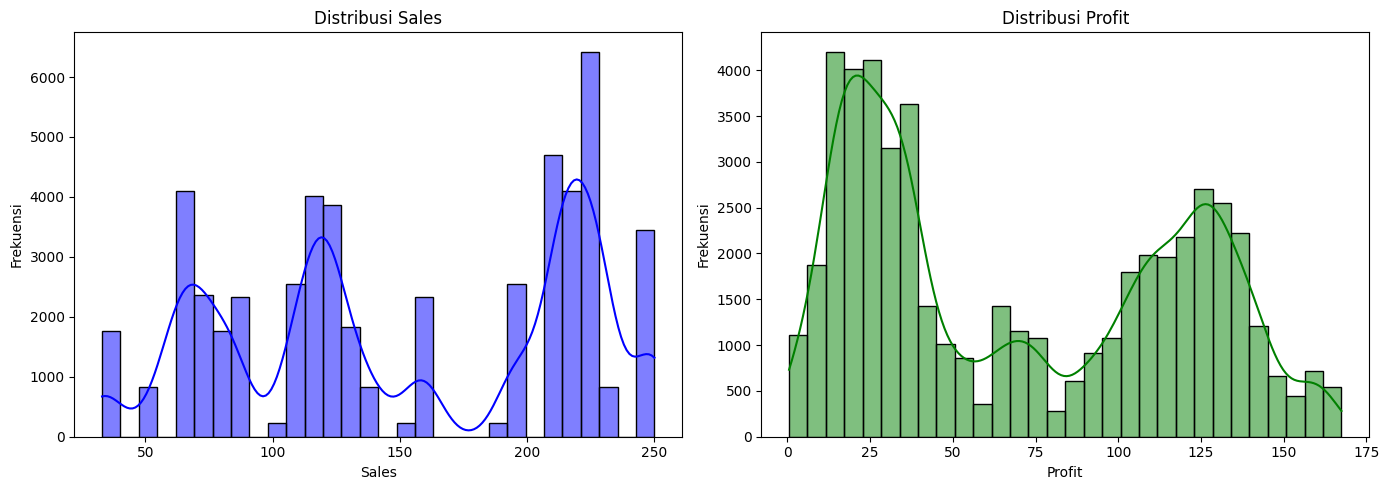

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi Sales
sns.histplot(df['Sales'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribusi Sales')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frekuensi')

# Distribusi Profit
sns.histplot(df['Profit'], bins=30, kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribusi Profit')
axes[1].set_xlabel('Profit')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

In [12]:
print("Skewness Sales:", df_clean['Sales'].skew())
print("Skewness Profit:", df_clean['Profit'].skew())

Skewness Sales: -0.08782259357901023
Skewness Profit: 0.2610598491894399


Distribusi Sales menunjukkan beberapa konsentrasi nilai pada rentang tertentu (di dalam rentang 50 - 100, 100 - 150, dan 200 - 250), sedangkan Profit memperlihatkan dua konsentrasi utama pada tingkat profit yang lebih rendah dan lebih tinggi (di dalam rentang 15 - 35 dan 100 - 135). Hal ini menunjukkan adanya variasi karakteristik transaksi yang cukup jelas dalam dataset yang digunakan.


##C.3.) IQR Analysis

In [13]:
for col in ['Sales', 'Profit']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]

    print(f"\n{col}")
    print(f"Q1            : {Q1:.2f}")
    print(f"Q3            : {Q3:.2f}")
    print(f"IQR           : {IQR:.2f}")
    print(f"Batas bawah   : {lower:.2f}")
    print(f"Batas atas    : {upper:.2f}")
    print(f"Outlier       : {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}%)")


Sales
Q1            : 85.00
Q3            : 218.00
IQR           : 133.00
Batas bawah   : -114.50
Batas atas    : 417.50
Outlier       : 0 (0.00%)

Profit
Q1            : 24.90
Q3            : 118.40
IQR           : 93.50
Batas bawah   : -115.35
Batas atas    : 258.65
Outlier       : 0 (0.00%)


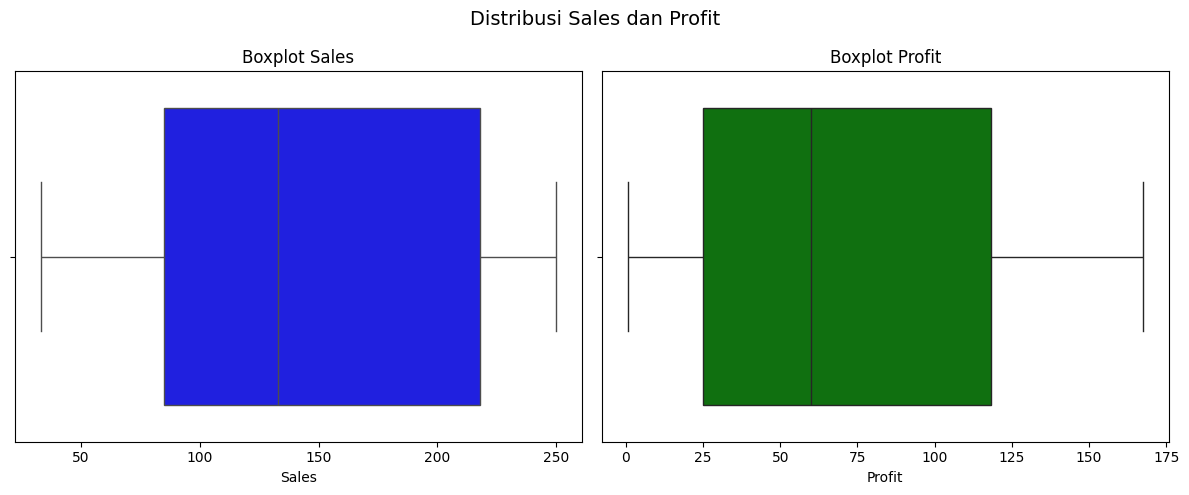

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot Sales
sns.boxplot(x=df_clean['Sales'], ax=axes[0], color='blue')
axes[0].set_title('Boxplot Sales')
axes[0].set_xlabel('Sales')

# Boxplot Profit
sns.boxplot(x=df_clean['Profit'], ax=axes[1], color='green')
axes[1].set_title('Boxplot Profit')
axes[1].set_xlabel('Profit')

plt.suptitle('Distribusi Sales dan Profit', fontsize=14)
plt.tight_layout()
plt.show()

Berdasarkan metode IQR dengan batas 1,5 × IQR, tidak ditemukan potential outlier pada variabel Sales maupun Profit. Hal ini menunjukkan bahwa seluruh observasi masih berada dalam batas distribusi yang ditentukan oleh metode IQR.

##C.4.) Correlation Analysis per Metrics

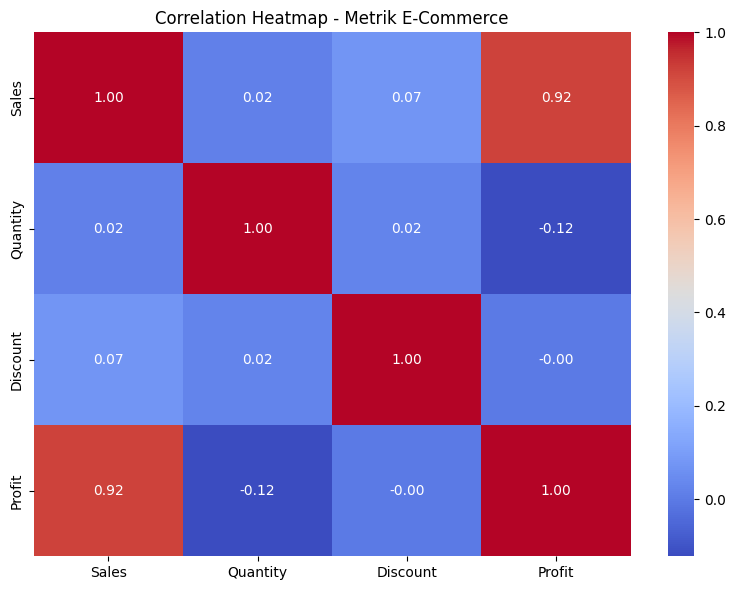

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

metrics = ['Sales', 'Quantity', 'Discount', 'Profit']
corr_matrix = df_clean[metrics].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Metrik E-Commerce')
plt.tight_layout()
plt.show()

Berdasarkan hasil visualisasi heatmap diatas, ditemukan beberapa hal yaitu sebagai berikut:

1.) Korelasi Discount vs Profit **(-0.00)**: Hampir tidak ada hubungan linear antara Discount dan Profit. Artinya, dari sisi statistik, besar-kecilnya diskon yang dikasih tidak berpengaruh signifikan terhadap besar-kecilnya profit yang dihasilkan. Temuan ini dapat menjawab salah satu pertanyaan bisnis yang ada, yaitu tingkat discount belum tentu mempengaruhi tingkat profit yang diterima oleh perusahaan.

2.) Korelasi Sales vs Discount **(0.07)**: Sama seperti Discount, Sales hampir tidak memiliki korelasi dengan Discount. Ini mengindikasikan bahwa secara umum, besaran diskon yang diberikan tidak memiliki hubungan linear yang signifikan terhadap performa penjualan secara keseluruhan.

3.) Korelasi Sales vs Profit **(0.92)**: Semakin besar nilai penjualan, semakin besar juga profitnya. Ini hubungan yang paling kuat di seluruh metrik yang ada, hal ini wajar karena Profit itu merupakan turunan dari transaksi yang nilainya juga besar.



#C.5.) Discount vs Profit, categorized by customer demographics (gender)

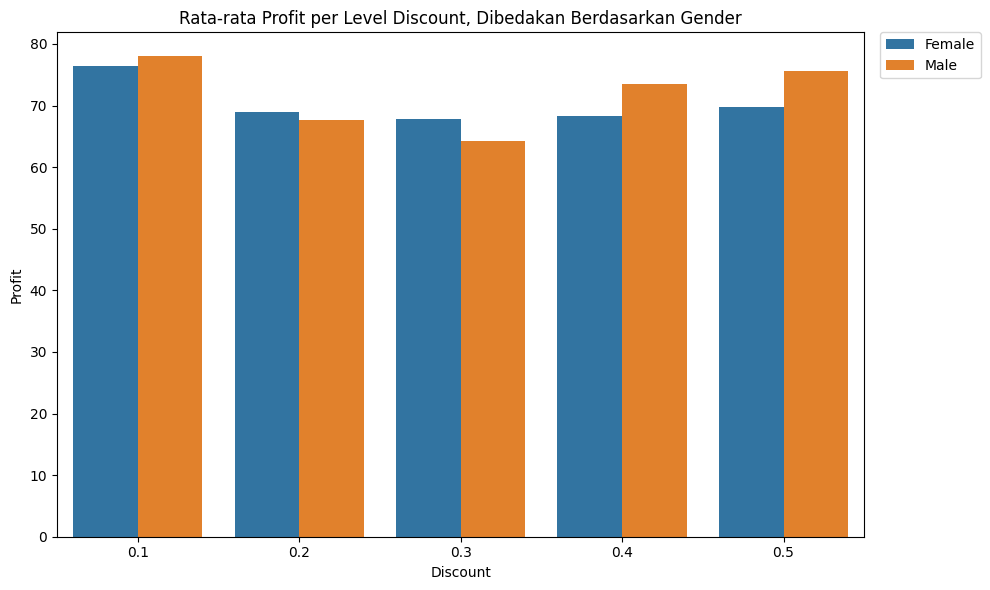

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_clean, x='Discount', y='Profit', hue='Gender', errorbar=None)
plt.title('Rata-rata Profit per Level Discount, Dibedakan Berdasarkan Gender')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

In [17]:
# Pivot rata-rata Profit per Discount x Gender
pivot = df_clean.groupby(['Discount','Gender'])['Profit'].mean().unstack()
print('Rata-rata Profit per Discount x Gender')
print(pivot.round(2))

# Rentang (max-min) rata-rata Profit per gender
print("\nRange (max-min) profit per gender:")
print((pivot.max() - pivot.min()).round(2))

# Std deviasi rata-rata Profit per gender
print("\nStd per gender:")
print(pivot.std().round(2))

Rata-rata Profit per Discount x Gender
Gender    Female   Male
Discount               
0.1        76.39  77.99
0.2        68.93  67.65
0.3        67.88  64.32
0.4        68.26  73.51
0.5        69.77  75.61

Range (max-min) profit per gender:
Gender
Female     8.51
Male      13.67
dtype: float64

Std per gender:
Gender
Female    3.51
Male      5.68
dtype: float64


Rata-rata Profit pada customer laki-laki menunjukkan variasi yang lebih besar antar level Discount **(rentang 13,67, std 5,68)** dibandingkan perempuan **(rentang 8,51, std 3,51)**. Pola ini bukan tren linear, yang mana profit tidak konsisten naik atau turun searah dengan besaran diskon. Profit pada laki-laki justru terendah di Discount **0,3** dan tertinggi di Discount **0,1** dan **0,5**. Oleh karena itu, diperlukan analisis lebih lanjut terhadap pengaruh kategori produk terhadap profit untuk memahami penyebab variasi ini.

##C.6.) Discount vs Profit, categorized by product category

In [18]:
# Rata-rata Profit per kategori produk
baseline_df = df_clean.groupby('Product_Category')['Profit'].mean().round(2).sort_values(ascending=False).reset_index()
baseline_df.columns = ['Product_Category', 'avg_profit']
baseline_df

,Product_Category,avg_profit
0,Fashion,80.82
1,Auto & Accessories,64.49
2,Electronic,64.49
3,Home & Furniture,57.01


In [19]:
# Breakdown: rata-rata Profit per Discount x Product_Category
breakdown_df = df_clean.groupby(['Discount','Product_Category'])['Profit'].mean().round(2).unstack()
breakdown_df

Product_Category,Auto & Accessories,Electronic,Fashion,Home & Furniture
Discount,,,,
0.1,71.70,67.15,88.81,63.58
0.2,65.50,62.69,86.04,61.00
0.3,58.98,NaN,83.00,55.73
0.4,NaN,NaN,79.31,52.37
0.5,NaN,NaN,76.08,50.30


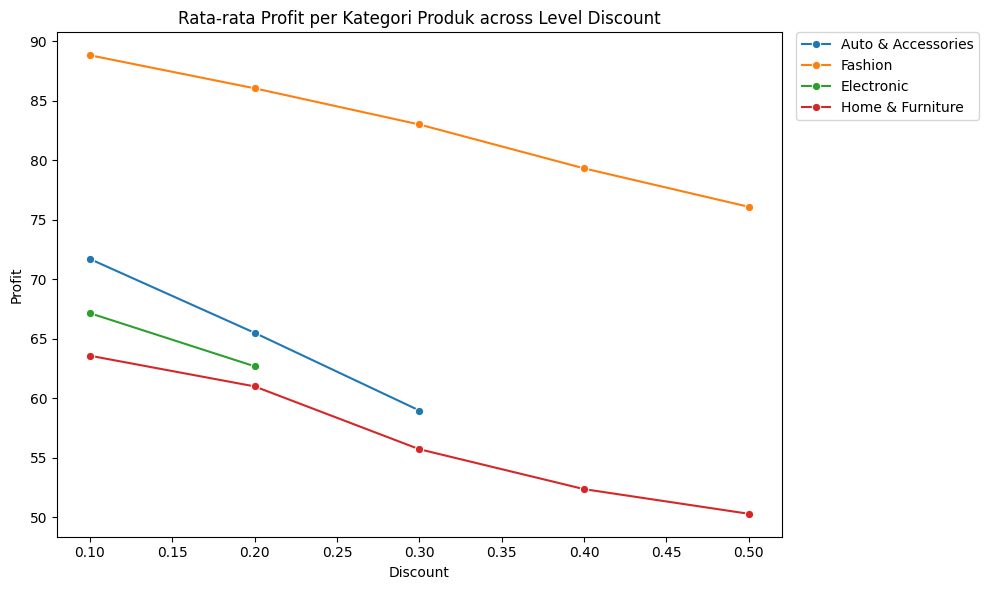

In [20]:
plt.figure(figsize=(10,6))

sns.lineplot(data=df_clean, x='Discount', y='Profit', hue='Product_Category', marker='o', errorbar=None)
plt.title('Rata-rata Profit per Kategori Produk across Level Discount')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

Analisis lanjutan terhadap pengaruh kategori produk terhadap Profit dilakukan untuk menjawab dugaan yang muncul dari temuan sebelumnya. Berdasarkan hasil visualisasi chart diatas, profit tiap kategori produk pada berbagai level Discount. Fashion secara konsisten mencatatkan Profit tertinggi di semua level diskon (88,81 di Discount 0,1 hingga 76,08 di Discount 0,5), diikuti Home & Furniture di posisi terendah namun tetap tersedia di seluruh level diskon.

Sementara itu, Auto & Accessories dan Electronic hanya muncul pada level diskon rendah (0,1–0,3 dan 0,1–0,2), tidak tersedia pada diskon 0,4 dan 0,5. Hal ini mengkonfirmasi bahwa komposisi kategori produk berbeda pada tiap level diskon. **sehingga fluktuasi rata-rata Profit yang terlihat pada segmen laki-laki sebelumnya lebih tepat dijelaskan oleh pergeseran kategori produk yang tersedia di tiap level diskon, bukan oleh gender itu sendiri.**

Untuk memvalidasi temuan di atas secara statistik, dilakukan pengujian statistik menggunakan One-Way ANOVA dan Eta Squared terhadap Product_Category dan Gender. ANOVA digunakan untuk menguji signifikansi perbedaan rata-rata Profit antar kelompok, sementara Eta Squared mengukur seberapa besar proporsi variansi Profit yang dijelaskan oleh masing-masing variabel.




In [21]:
# Gender -> Profit
groups_gender = [g['Profit'].values for _, g in df_clean.groupby('Gender')]
f_g, p_g = stats.f_oneway(*groups_gender)
grand_mean = df_clean['Profit'].mean()
ss_between_g = sum(len(g)*(g['Profit'].mean()-grand_mean)**2 for _, g in df_clean.groupby('Gender'))
ss_total = sum((df_clean['Profit']-grand_mean)**2)
eta_g = ss_between_g/ss_total
print(f"Gender -> Profit: F={f_g:.4f}, p-value={p_g:.6f}, Eta Squared={eta_g:.6f} ({eta_g*100:.2f}%)")

# Product_Category -> Profit
groups_cat = [g['Profit'].values for _, g in df_clean.groupby('Product_Category')]
f_c, p_c = stats.f_oneway(*groups_cat)
ss_between_c = sum(len(g)*(g['Profit'].mean()-grand_mean)**2 for _, g in df_clean.groupby('Product_Category'))
eta_c = ss_between_c/ss_total
print(f"Product_Category -> Profit: F={f_c:.4f}, p-value={p_c:.6f}, Eta Squared={eta_c:.6f} ({eta_c*100:.2f}%)")

Gender -> Profit: F=3.0751, p-value=0.079507, Eta Squared=0.000060 (0.01%)
Product_Category -> Profit: F=871.5107, p-value=0.000000, Eta Squared=0.048515 (4.85%)


Hasil pengujian menunjukkan bahwa Gender tidak memiliki pengaruh yang signifikan terhadap Profit **(F= 3,0751, p= 0,079507; Eta Squared= 0,006%)**, yang berarti tidak terdapat cukup bukti statistik bahwa rata-rata Profit antara pelanggan laki-laki dan perempuan berbeda secara nyata. Sebaliknya, Product_Category terbukti berpengaruh signifikan terhadap Profit baik secara statistik maupun praktis **(F= 871,5107, p≈0; Eta Squared= 4,85%)**.

Temuan ini menunjukkan bahwa kategori produk merupakan faktor yang jauh lebih relevan dalam menjelaskan variasi Profit dibandingkan Gender. Sehingga strategi bisnis untuk meningkatkan profitabilitas sebaiknya difokuskan pada pendekatan berbasis kategori produk, bukan segmentasi berdasarkan gender.

Namun temuan tersebut masih menyisakan pertanyaan yang belum terjawab:

**<< Jika diskon yang diberikan secara seragam ke pelanggan terbukti kurang membedakan nilai customer, lalu kepada kelompok pelanggan yang seperti apa diskon seharusnya diberikan lebih besar atau lebih kecil? >>**

Kategori produk membantu menjelaskan max profit per transaksi. Untuk menentukan **target diskon**, unit keputusannya tetap pelanggan. Karena itu analisis dilanjutkan ke Customer Segmentation berbasis **RFM**.


# D.) CUSTOMER SEGMENTATION

Setelah EDA pada tingkat transaksi selesai, analisis dilanjutkan ke tingkat pelanggan. Tujuannya adalah mengelompokkan customer berdasarkan Recency, Frequency, dan Monetary, kemudian menilai apakah rata-rata diskon yang selama ini diberikan sudah berbeda antarsehmen. Hasil pengelompokan tersebut dipakai sebagai dasar penyusunan strategi diskon yang lebih tepat sasaran.


## D.1.) Agregasi ke level customer (RFM)

Karena dataset masih berbentuk transaksi, data perlu diagregasi ke level Customer_Id sebelum clustering dilakukan.

- **Recency**: jumlah hari sejak transaksi terakhir hingga tanggal acuan analisis
- **Frequency**: jumlah transaksi yang pernah dilakukan customer
- **Monetary**: total revenue yang dihasilkan customer, dihitung dari `Sales × Quantity`


In [22]:
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'])
df_clean['Revenue'] = df_clean['Sales'] * df_clean['Quantity']

snapshot = df_clean['Order_Date'].max() + timedelta(days=1)
print('Snapshot date:', snapshot.date())

last_order = df_clean.groupby('Customer_Id')['Order_Date'].max()
freq = df_clean.groupby('Customer_Id')['Order_Date'].count()
monetary = df_clean.groupby('Customer_Id')['Revenue'].sum()
profit = df_clean.groupby('Customer_Id')['Profit'].sum()
avg_disc = df_clean.groupby('Customer_Id')['Discount'].mean()

customer_df = pd.DataFrame({
    'Recency': (snapshot - last_order).dt.days,
    'Frequency': freq,
    'Monetary': monetary,
    'Total_Profit': profit,
    'Avg_Discount': avg_disc
}).reset_index()

print('Jumlah customer:', len(customer_df))
customer_df.head()


Snapshot date: 2018-12-31
Jumlah customer: 38989


,Customer_Id,Recency,Frequency,Monetary,Total_Profit,Avg_Discount
0,10000,25,2,293.0,167.1,0.30
1,10002,133,1,298.0,66.0,0.10
2,10004,145,1,340.0,1.6,0.50
3,10006,145,2,660.0,269.0,0.15
4,10013,228,1,159.0,74.2,0.30


Hasil agregasi menghasilkan satu observasi untuk setiap `Customer_Id`. Dengan demikian, unit analisis pada tahap ini sudah berpindah dari transaksi ke pelanggan, sesuai pertanyaan bisnis mengenai target diskon.


In [23]:
print(customer_df[['Recency', 'Frequency', 'Monetary', 'Total_Profit', 'Avg_Discount']].describe().round(2))
print('\nDistribusi Frequency:')
print(customer_df['Frequency'].value_counts().sort_index())


        Recency  Frequency  Monetary  Total_Profit  Avg_Discount
count  38989.00   38989.00  38989.00      38989.00      38989.00
mean     144.11       1.32    503.53         92.60          0.30
std       96.35       0.58    416.26         69.23          0.12
min        1.00       1.00     33.00          0.50          0.10
25%       59.00       1.00    211.00         31.60          0.20
50%      134.00       1.00    381.00         90.40          0.30
75%      222.00       2.00    700.00        133.00          0.40
max      364.00       6.00   4029.00        546.90          0.50

Distribusi Frequency:
Frequency
1    28824
2     8321
3     1595
4      216
5       32
6        1
Name: count, dtype: int64


Berdasarkan statistik deskriptif RFM, rata-rata Frequency hanya sebesar **1,32** dengan median **1**. Sebagian besar pelanggan hanya bertransaksi satu kali, sementara Frequency maksimum hanya mencapai 6. Distribusi Monetary juga cukup lebar, dengan rata-rata **503,53** dan nilai maksimum **4.029**.

Temuan ini menunjukkan bahwa basis pelanggan pada dataset didominasi oleh one-time buyer. Oleh karena itu, segmentasi yang terbentuk diperkirakan akan lebih banyak memisahkan pelanggan berdasarkan recency dan nilai belanja one-timer, serta memisahkan kelompok kecil pelanggan yang sudah melakukan pembelian berulang.


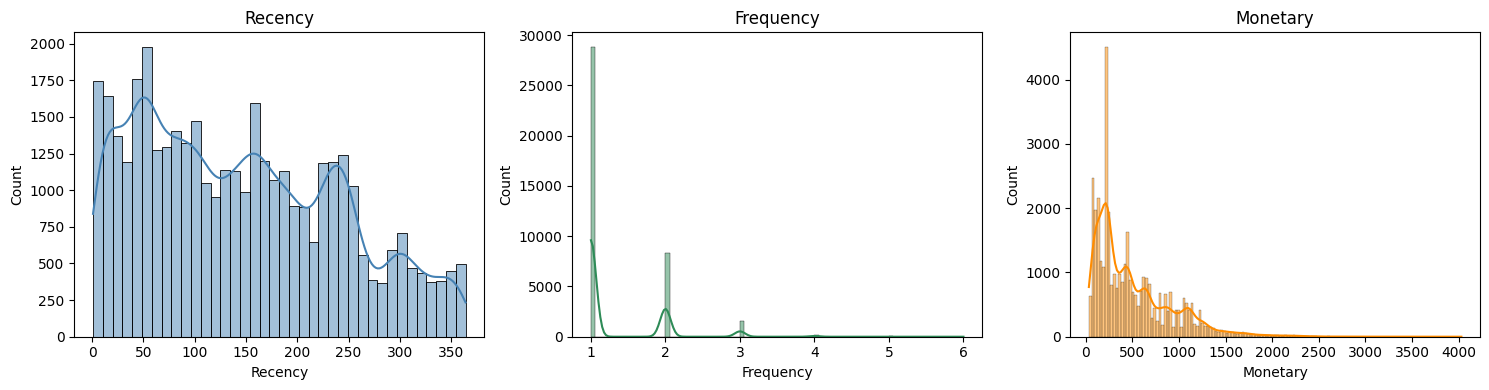

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(customer_df['Recency'], ax=axes[0], kde=True, color='steelblue')
axes[0].set_title('Recency')

sns.histplot(customer_df['Frequency'], ax=axes[1], kde=True, color='seagreen')
axes[1].set_title('Frequency')

sns.histplot(customer_df['Monetary'], ax=axes[2], kde=True, color='darkorange')
axes[2].set_title('Monetary')

plt.tight_layout()
plt.show()


Distribusi Recency tersebar dari pelanggan yang baru bertransaksi hingga pelanggan yang sudah lama tidak aktif.

Frequency menumpuk pada nilai 1, sementara Monetary memperlihatkan ekor ke kanan yang menandakan adanya pelanggan dengan nilai belanja relatif tinggi.

Pola tersebut memperkuat hasil deskriptif sebelumnya dan menjadi dasar penggunaan ketiga variabel RFM sebagai input clustering.


## D.2.) Scaling dan pemilihan jumlah cluster

Recency, Frequency, dan Monetary memiliki satuan serta rentang nilai yang berbeda. Agar tidak ada variabel yang mendominasi proses clustering hanya karena skalanya lebih besar, ketiga fitur distandardisasi menggunakan StandardScaler.

Jumlah cluster ditentukan melalui Elbow Method. Inertia dihitung untuk k = 2 sampai k = 7. Semakin kecil inertia, semakin rapat observasi di dalam clusternya. Jumlah cluster yang dipilih adalah titik di mana penurunan inertia mulai melambat, dengan tetap mempertimbangkan kebutuhan bisnis untuk membedakan treatment diskon.


k = 2 | inertia = 71709.0
k = 3 | inertia = 49770.0
k = 4 | inertia = 39755.0
k = 5 | inertia = 31942.0
k = 6 | inertia = 27986.0
k = 7 | inertia = 24090.0


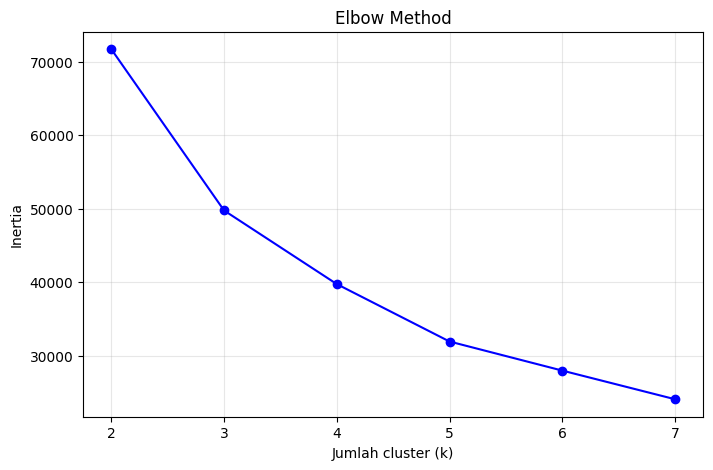

In [25]:
X = StandardScaler().fit_transform(customer_df[['Recency', 'Frequency', 'Monetary']])

inertia = []
for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)
    print('k =', k, '| inertia =', round(model.inertia_, 0))

plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), inertia, 'bo-')
plt.xlabel('Jumlah cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True, alpha=0.3)
plt.show()


Hasil Elbow Method menunjukkan penurunan inertia yang cukup tajam dari k = 2 ke k = 4, kemudian menjadi lebih landai setelahnya. Meskipun k = 2 secara geometri lebih sederhana, pemisahan tersebut hanya membedakan pelanggan one-timer dan repeat secara kasar.

Untuk keperluan strategi diskon, **k = 4** dipilih karena menghasilkan kelompok yang lebih operasional: pelanggan bernilai tinggi, pelanggan repeat menengah, one-timer yang masih relatif baru, dan one-timer yang sudah lama tidak aktif.


In [26]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_df['Cluster'] = kmeans.fit_predict(X)
print(customer_df['Cluster'].value_counts().sort_index())


Cluster
0    13286
1    15738
2     6496
3     3469
Name: count, dtype: int64


K-Means memberikan label cluster berupa angka 0 sampai 3. Label tersebut belum memiliki makna bisnis, sehingga perlu dibaca melalui rata-rata Recency, Frequency, Monetary, kontribusi profit, dan rata-rata diskon pada masing-masing cluster.


## D.3.) Profiling cluster


In [27]:
profil = customer_df.groupby('Cluster').agg(
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
    Total_Profit=('Total_Profit', 'sum'),
    Avg_Discount=('Avg_Discount', 'mean'),
    n=('Customer_Id', 'count')
).round(2)

profil['%cust'] = (profil['n'] / profil['n'].sum() * 100).round(1)
profil['%profit'] = (profil['Total_Profit'] / profil['Total_Profit'].sum() * 100).round(1)
profil


,Recency,Frequency,Monetary,Total_Profit,Avg_Discount,n,%cust,%profit
Cluster,,,,,,,,
0,252.49,1.02,380.59,945703.7,0.31,13286,34.1,26.2
1,84.28,1.00,382.50,1116585.4,0.30,15738,40.4,30.9
2,95.69,2.07,566.84,840085.0,0.30,6496,16.7,23.3
3,91.12,2.48,1404.91,707962.3,0.31,3469,8.9,19.6


Tabel profil menunjukkan perbedaan karakteristik yang cukup jelas antar kelompok.

Cluster dengan Frequency mendekati 1 dan Recency tinggi merepresentasikan pelanggan yang hanya bertransaksi sekali lalu tidak kembali dalam waktu lama. Cluster dengan Frequency mendekati 1 tetapi Recency lebih rendah merepresentasikan one-timer yang masih relatif baru. Dua cluster sisanya memiliki Frequency di atas 2; salah satunya mencatat Monetary tertinggi dan dapat dikategorikan sebagai pelanggan bernilai tinggi.

Temuan penting lain terdapat pada kolom rata-rata diskon. Nilai Avg_Discount di keempat cluster berada di sekitar **0,30**. Artinya, meskipun perilaku belanja dan kontribusi profit berbeda, tingkat diskon yang diterima pelanggan masih relatif seragam. Hasil ini sejalan dengan temuan EDA bahwa pemberian diskon belum membedakan nilai pelanggan.


In [28]:
# Penamaan cluster berdasarkan ciri pada tabel profil
nama_cluster = {
    0: 'Lost One-timer',
    1: 'Recent One-timer',
    2: 'Repeat Mid-value',
    3: 'High-value Repeat'
}

customer_df['Segment'] = customer_df['Cluster'].map(nama_cluster)
print(customer_df['Segment'].value_counts())

profile = customer_df.groupby('Segment').agg(
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
    Total_Profit=('Total_Profit', 'sum'),
    Avg_Discount=('Avg_Discount', 'mean'),
    Jumlah=('Customer_Id', 'count')
).round(2)

profile['%customer'] = (profile['Jumlah'] / profile['Jumlah'].sum() * 100).round(1)
profile['%profit'] = (profile['Total_Profit'] / profile['Total_Profit'].sum() * 100).round(1)
profile


Segment
Recent One-timer     15738
Lost One-timer       13286
Repeat Mid-value      6496
High-value Repeat     3469
Name: count, dtype: int64


,Recency,Frequency,Monetary,Total_Profit,Avg_Discount,Jumlah,%customer,%profit
Segment,,,,,,,,
High-value Repeat,91.12,2.48,1404.91,707962.3,0.31,3469,8.9,19.6
Lost One-timer,252.49,1.02,380.59,945703.7,0.31,13286,34.1,26.2
Recent One-timer,84.28,1.00,382.50,1116585.4,0.30,15738,40.4,30.9
Repeat Mid-value,95.69,2.07,566.84,840085.0,0.30,6496,16.7,23.3


Setelah diberi label, keempat segmen dapat diinterpretasikan sebagai berikut.

**High-value Repeat** memiliki porsi pelanggan yang relatif kecil, yaitu sekitar **8,9%**, tetapi menyumbang sekitar **19,6%** total profit. Segmen ini merupakan kelompok dengan nilai belanja dan frequency tertinggi.

**Repeat Mid-value** mencakup sekitar **16,7%** pelanggan dan **23,3%** profit. Kelompok ini sudah melakukan pembelian berulang, namun nilai belanjanya belum setinggi segmen High-value Repeat.

**Recent One-timer** merupakan segmen terbesar, sekitar **40,4%** pelanggan dengan kontribusi profit **30,9%**. Karakteristik utamanya adalah Frequency = 1 dan Recency yang masih relatif rendah.

**Lost One-timer** mencakup sekitar **34,1%** pelanggan dan **26,2%** profit. Sama seperti Recent One-timer, kelompok ini hanya bertransaksi sekali, tetapi Recency-nya jauh lebih tinggi.

Perbedaan kontribusi profit dan perilaku belanja tersebut menjadi dasar untuk membedakan strategi diskon antar segmen.


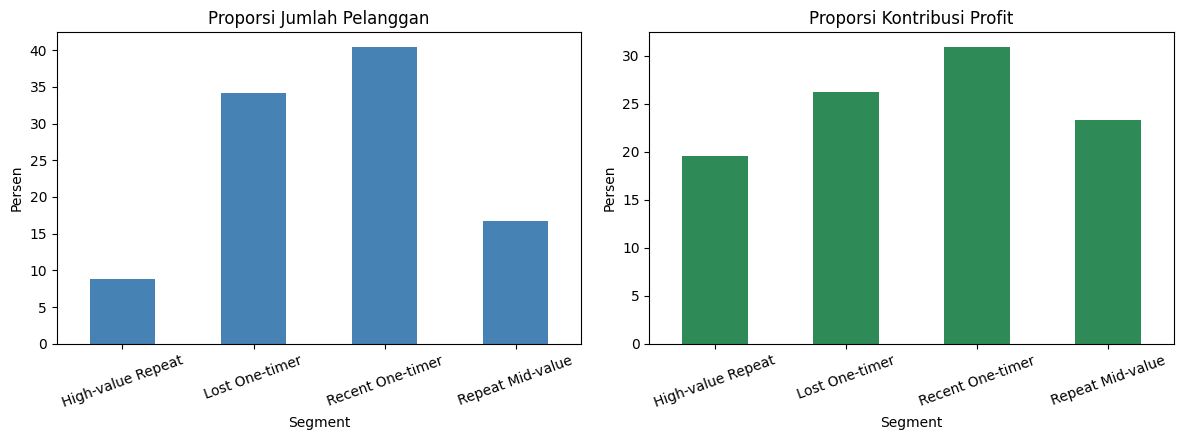

In [29]:
# Visualisasi jumlah pelanggan dan kontribusi profit berdasarkan segmentasi customer

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

profile['%customer'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Proporsi Jumlah Pelanggan')
axes[0].set_ylabel('Persen')
axes[0].tick_params(axis='x', rotation=20)

profile['%profit'].plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Proporsi Kontribusi Profit')
axes[1].set_ylabel('Persen')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


Recent One-timer dan Lost One-timer mendominasi jumlah pelanggan, tetapi High-value Repeat memberikan kontribusi profit yang lebih padat dibanding porsi jumlahnya. Ketimpangan ini menjadi alasan treatment diskon tidak seharusnya diseragamkan.


In [30]:
# Kategori produk yang paling sering muncul di tiap customer
kategori_utama = (
    df_clean.groupby('Customer_Id')['Product_Category']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
)
kategori_utama.columns = ['Customer_Id', 'Dominant_Category']

customer_df = customer_df.merge(kategori_utama, on='Customer_Id', how='left')

pd.crosstab(customer_df['Segment'], customer_df['Dominant_Category'], normalize='index').round(3) * 100


Dominant_Category,Auto & Accessories,Electronic,Fashion,Home & Furniture
Segment,,,,
High-value Repeat,15.2,1.2,50.6,33.1
Lost One-timer,15.4,5.9,50.8,27.9
Recent One-timer,16.6,5.6,50.3,27.5
Repeat Mid-value,19.7,2.5,39.8,38.0


Komposisi kategori produk antar segmen tidak menunjukkan perbedaan yang ekstrem. Fashion tetap menjadi kategori dominan di semua kelompok, diikuti Home & Furniture.

Dengan demikian, perbedaan segmen lebih banyak dijelaskan oleh perilaku belanja RFM, bukan oleh spesialisasi kategori yang mencolok. Kategori produk tetap relevan sebagai konteks transaksi, sebagaimana ditemukan pada EDA, tetapi tidak menggantikan segmentasi pelanggan sebagai dasar target diskon.


##D.4.) Efektivitas Diskon Terhadap Pemasukan Profit Dari Setiap Segmen

In [31]:
# Revenue per-transaksi
df_clean['Revenue'] = df_clean['Sales'] * df_clean['Quantity']

# Discount cost per-transaksi
df_clean['Discount_Cost'] = df_clean['Revenue'] * df_clean['Discount']

# Agregasi ke level customer
discount_cost = df_clean.groupby('Customer_Id')['Discount_Cost'].sum()
customer_df = customer_df.merge(discount_cost.rename('Total_Discount_Cost'), on='Customer_Id', how='left')

# ROI per segmen -> profit yang dihasilkan per Rp.1 diskon yang dikeluarkan
roi = customer_df.groupby('Segment').agg(
    Total_Profit=('Total_Profit', 'sum'),
    Total_Discount_Cost=('Total_Discount_Cost', 'sum'),
    Jumlah_Customer=('Customer_Id', 'count')
)

roi['Profit_per_Rp_Diskon'] = roi['Total_Profit'] / roi['Total_Discount_Cost']
roi['Profit_per_Customer'] = roi['Total_Profit'] / roi['Jumlah_Customer']
roi = roi.sort_values('Profit_per_Rp_Diskon', ascending=False)
roi

,Total_Profit,Total_Discount_Cost,Jumlah_Customer,Profit_per_Rp_Diskon,Profit_per_Customer
Segment,,,,,
Repeat Mid-value,840085.0,1119315.3,6496,0.750535,129.323430
Recent One-timer,1116585.4,1866229.4,15738,0.598311,70.948367
Lost One-timer,945703.7,1580707.4,13286,0.598279,71.180468
High-value Repeat,707962.3,1516172.2,3469,0.466941,204.082531


/tmp/ipykernel_1352/4008366114.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=roi.index, y=roi['Profit_per_Rp_Diskon'], palette='Blues_d')


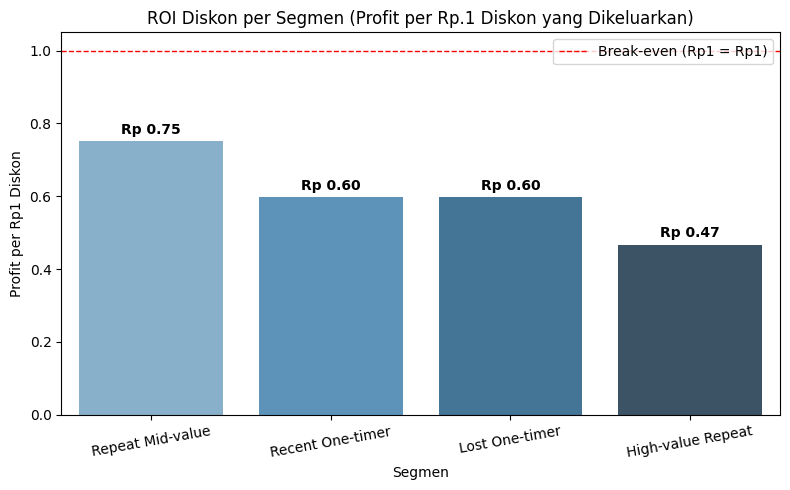

In [32]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=roi.index, y=roi['Profit_per_Rp_Diskon'], palette='Blues_d')

for i, v in enumerate(roi['Profit_per_Rp_Diskon']):
    ax.text(i, v + 0.02, f'Rp {v:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.axhline(1, color='red', linestyle='--', linewidth=1, label='Break-even (Rp1 = Rp1)')
plt.ylabel('Profit per Rp1 Diskon')
plt.xlabel('Segmen')
plt.title('ROI Diskon per Segmen (Profit per Rp.1 Diskon yang Dikeluarkan)')
plt.xticks(rotation=10)
plt.legend()
plt.tight_layout()
plt.show()

Meskipun seluruh segmen tetap menghasilkan profit, efisiensi diskon bervariasi signifikan antar segmen. High-value Repeat menunjukkan efisiensi diskon paling rendah (Rp0,47 profit per Rp.1 diskon) meskipun menyumbang total profit yang paling banyak dibandingkan dengan segmen lainnya, sementara Repeat Mid-value paling efisien (Rp.0,75). Ini mengindikasikan ada ruang untuk mengoptimalkan alokasi diskon, bukan menghapusnya.

## D.5.) Rekomendasi strategi diskon

Berdasarkan profil RFM dan temuan bahwa rata-rata diskon masih seragam di semua segmen, strategi berikut diusulkan:

1. High-value Repeat
Porsi pelanggan sekitar 8,9%, kontribusi profit sekitar 19,6%. Frequency dan Monetary-nya paling tinggi.
Rekomendasi: turunkan diskon, atau ganti sebagian potongan harga dengan benefit non-harga seperti free shipping, prioritas layanan, atau poin loyalitas.
Alasan: kelompok ini sudah bernilai tinggi. Diskon dalam hanya berpotensi menggerus margin tanpa banyak menambah frekuensi belanja.

2. Repeat Mid-value
Porsi pelanggan sekitar 16,7%, kontribusi profit sekitar 23,3%. Sudah repeat, tetapi nilai belanjanya belum setinggi segmen atas.
Rekomendasi: pertahankan diskon moderat, lalu padukan dengan bundling atau ambang minimal belanja.
Alasan: segmen ini punya sinyal pembelian berulang. Yang perlu didorong bukan sekadar transaksi ulang, melainkan peningkatan nilai transaksi agar naik ke High-value Repeat.

3. Recent One-timer
Segmen terbesar: sekitar 40,4% pelanggan dan 30,9% profit. Baru bertransaksi sekali dan Recency-nya masih relatif rendah.
Rekomendasi: berikan diskon terbatas, berlaku untuk pembelian kedua dan berbatas waktu.
Alasan: ini kolam konversi paling rasional. Recency yang masih rendah membuat peluang pembelian ulang lebih masuk akal dibanding one-timer yang sudah lama hilang.

4. Lost One-timer
Porsi pelanggan sekitar 34,1%, kontribusi profit sekitar 26,2%. Hanya belanja sekali dan sudah lama tidak aktif.
Rekomendasi: batasi diskon, dan jangan masukkan ke campaign massal. Win-back hanya selektif.
Alasan: probabilitas kembali lebih rendah. Memberi diskon 30% ke kelompok ini paling berisiko membuang anggaran tanpa hasil yang sebanding.

Rekomendasi tersebut bersifat arah kebijakan berdasarkan perbedaan nilai dan perilaku pelanggan. Pengujian lebih lanjut tetap diperlukan sebelum diterapkan secara penuh. Langkah yang paling rasional untuk dimulai adalah pembatasan diskon pada Lost One-timer, diikuti uji penawaran pembelian kedua pada Recent One-timer.


# E.) Kesimpulan

1.) Analisis EDA menunjukkan bahwa hubungan agregat antara diskon dan profit tidak bersifat linear, gender tidak berpengaruh signifikan terhadap profit, dan kategori produk lebih mampu menjelaskan variasi profit pada tingkat transaksi. Namun, temuan tersebut belum menjawab kepada kelompok pelanggan mana diskon seharusnya dialokasikan.

2.) Segmentasi RFM kemudian membagi pelanggan menjadi empat kelompok dengan kontribusi profit dan pola belanja yang berbeda. Temuan kuncinya adalah keempat segmen masih menerima rata-rata diskon yang hampir sama, yaitu sekitar 30%.

3.) Dengan membedakan treatment diskon berdasarkan segmen, perusahaan memiliki dasar yang lebih kuat untuk mengefisienkan anggaran promo, menjaga margin pada High-value Repeat, mendorong peningkatan nilai pada Repeat Mid-value, mengonversi Recent One-timer, serta membatasi diskon pada Lost One-timer.


In [33]:
df_clean.to_csv('Dataset.csv', index=False)